# Practica 2 — Modelado, Calibracion e Incertidumbre

In [ ]:
import sys, json, warnings, pickle
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    matthews_corrcoef, roc_auc_score, average_precision_score,
    log_loss, brier_score_loss, roc_curve, classification_report
)
from sklearn.model_selection import train_test_split
from sklearn.calibration import CalibratedClassifierCV, calibration_curve

warnings.filterwarnings("ignore")
np.random.seed(42)

ART_DIR = Path("artifacts")
ART_DIR.mkdir(exist_ok=True)

In [ ]:
import sys
import os

ruta_proyecto = os.path.abspath(os.path.join("practica2-modelado", "practica2-modelado"))
sys.path.append(ruta_proyecto)

from src.preprocessing.base_preprocessing import BasePreprocess
from src.filtering.base_filtering import BaseFiltering

preprocessor   = joblib.load("preprocessor.pkl")
feature_filter = joblib.load("filter.pkl")
print("preprocessor:", type(preprocessor).__name__)
print("filter:      ", type(feature_filter).__name__)

preprocessor: BasePreprocess
filter:       BaseFiltering


In [ ]:
# Preprocesar y filtrar
X_train_pre, y_train_pre = preprocessor.transform("df_train_small.csv")
X_test_pre,  y_test_pre  = preprocessor.transform("df_test_small.csv")

X_train_filtered = feature_filter.transform(X_train_pre)
X_test_filtered  = feature_filter.transform(X_test_pre)

y_train_flat = np.asarray(y_train_pre).ravel().astype(int)
y_test_flat  = np.asarray(y_test_pre).ravel().astype(int)

print(f"Train: {X_train_filtered.shape}  |  Test: {X_test_filtered.shape}")
print(f"Tasa impago train: {y_train_flat.mean():.4f}")

# scale_pos_weight para XGBoost
n_negative = np.sum(y_train_flat == 0)
n_positive = np.sum(y_train_flat == 1)
scale_pos_weight = n_negative / n_positive
print(f"scale_pos_weight = {scale_pos_weight:.2f}")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Train: (80000, 203)  |  Test: (20000, 203)
Tasa impago train: 0.2029
scale_pos_weight = 3.93


In [ ]:
# Split interno train/val
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_filtered, y_train_flat,
    test_size=0.2, random_state=42, stratify=y_train_flat
)
print(f"Train interno: {X_tr.shape}  |  Val interno: {X_val.shape}")

Train interno: (64000, 203)  |  Val interno: (16000, 203)


In [ ]:
def expected_calibration_error(y_true, y_prob, n_bins=10):
    """Expected Calibration Error (ECE)."""
    bins = np.linspace(0, 1, n_bins + 1)
    bin_idx = np.clip(np.digitize(y_prob, bins) - 1, 0, n_bins - 1)
    N = len(y_true)
    ece = 0.0
    for k in range(n_bins):
        mask = bin_idx == k
        n_k = mask.sum()
        if n_k == 0:
            continue
        ece += (n_k / N) * abs(y_prob[mask].mean() - y_true[mask].mean())
    return ece

def evaluate_model(model, X_eval, y_eval, model_name, results_dict):
    class_pred = model.predict(X_eval)
    prob_pred  = model.predict_proba(X_eval)[:, 1]
    results_dict[model_name] = {
        "Accuracy":  accuracy_score(y_eval, class_pred),
        "Precision": precision_score(y_eval, class_pred, zero_division=0),
        "Recall":    recall_score(y_eval, class_pred, zero_division=0),
        "F1":        f1_score(y_eval, class_pred, zero_division=0),
        "MCC":       matthews_corrcoef(y_eval, class_pred),
        "ROC-AUC":   roc_auc_score(y_eval, prob_pred),
        "PR-AUC":    average_precision_score(y_eval, prob_pred),
        "LogLoss":   log_loss(y_eval, prob_pred),
        "Brier":     brier_score_loss(y_eval, prob_pred),
        "ECE":       expected_calibration_error(y_eval, prob_pred),
        "prob_pred": prob_pred,
    }
    r = results_dict[model_name]
    print(f"\n{model_name}")
    print(f"  ROC-AUC={r['ROC-AUC']:.4f}  MCC={r['MCC']:.4f}  LogLoss={r['LogLoss']:.4f}  ECE={r['ECE']:.4f}")
    return results_dict

results = {}

## 1. Optimizacion con Optuna

Cambios:
- Log Loss en lugar de Brier. Log Loss penaliza calibracion y discriminacion conjuntamente.
- HyperbandPruner en lugar de MedianPruner. Hyperband asigna presupuesto de forma adaptativa y explora mas configuraciones.
- colsample_bynode en LightGBM y max_delta_step en XGBoost.

**Cada modelo se optimiza con y sin balanceo de clases.**

In [ ]:
import optuna
from optuna.samplers import TPESampler
from optuna.pruners import HyperbandPruner  
from optuna.integration import LightGBMPruningCallback, XGBoostPruningCallback
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
import lightgbm as lgb
from sklearn.metrics import log_loss as sk_log_loss

optuna.logging.set_verbosity(optuna.logging.WARNING)
N_TRIALS = 30

In [ ]:
def logloss_eval_lgbm(y_true, y_pred):
    y_pred = np.clip(np.asarray(y_pred, dtype=float), 1e-7, 1-1e-7)
    return "logloss", sk_log_loss(y_true, y_pred), False

def make_objective_lgbm(balanced):
    def objective(trial):
        params = {
            "n_estimators": 1000,
            "learning_rate":     trial.suggest_float("learning_rate", 5e-3, 0.3, log=True),
            "num_leaves":        trial.suggest_int("num_leaves", 15, 255),
            "max_depth":         trial.suggest_int("max_depth", 3, 12),
            "min_child_samples": trial.suggest_int("min_child_samples", 5, 100),
            "subsample":         trial.suggest_float("subsample", 0.5, 1.0),
            "subsample_freq": 1,
            "colsample_bytree":  trial.suggest_float("colsample_bytree", 0.5, 1.0),
            "colsample_bynode":  trial.suggest_float("colsample_bynode", 0.5, 1.0),  
            "reg_alpha":         trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
            "reg_lambda":        trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
            "min_split_gain":    trial.suggest_float("min_split_gain", 0.0, 0.5),
            "random_state": 42, "n_jobs": -1, "verbose": -1,
        }
        if balanced:
            params["class_weight"] = "balanced"
        model = LGBMClassifier(**params)
        pruning_cb = LightGBMPruningCallback(trial, metric="logloss", valid_name="valid_0")
        model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)],
                  eval_metric=logloss_eval_lgbm,
                  callbacks=[lgb.early_stopping(50, verbose=False), pruning_cb])
        return sk_log_loss(y_val, model.predict_proba(X_val)[:, 1])
    return objective

In [ ]:
def run_study(objective_factory, study_name, balanced):
    sampler = TPESampler(
        n_startup_trials=10,    # trials aleatorios antes de activar TPE
        multivariate=True,      # modela dependencias entre hiperparametros
        seed=42,
    )
    pruner  = HyperbandPruner(min_resource=1, max_resource=1000, reduction_factor=3)
    study   = optuna.create_study(
        direction="minimize", 
        sampler=sampler,
        pruner=pruner, 
        study_name=study_name
    )
    study.optimize(objective_factory(balanced), n_trials=N_TRIALS, show_progress_bar=True)
    print(f"[{study_name}] mejor LogLoss val = {study.best_value:.4f}")
    return study

study_lgbm_bal   = run_study(make_objective_lgbm, "lgbm_balanced",    balanced=True)
study_lgbm_nobal = run_study(make_objective_lgbm, "lgbm_nobalanced",  balanced=False)

  0%|          | 0/30 [00:00<?, ?it/s]

[lgbm_balanced] mejor LogLoss val = 0.4957


  0%|          | 0/30 [00:00<?, ?it/s]

[lgbm_nobalanced] mejor LogLoss val = 0.4595


In [ ]:
# Modelos LightGBM finales 
def fit_final_lgbm(study, balanced):
    params = dict(study.best_params)
    params.update({"n_estimators": 2000, 
                   "subsample_freq": 1,
                   "random_state": 42, 
                   "n_jobs": -1, 
                   "verbose": -1})
    if balanced:
        params["class_weight"] = "balanced"
    model = LGBMClassifier(**params)
    model.fit(X_tr, y_tr, 
              eval_set=[(X_val, y_val)],
              eval_metric=logloss_eval_lgbm,
              callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(0)])
    return model

lgbm_bal   = fit_final_lgbm(study_lgbm_bal,   balanced=True)
lgbm_nobal = fit_final_lgbm(study_lgbm_nobal, balanced=False)
results = evaluate_model(lgbm_bal,   X_test_filtered, y_test_flat, "LightGBM (balanced)",    results)
results = evaluate_model(lgbm_nobal, X_test_filtered, y_test_flat, "LightGBM (no balanced)", results)


LightGBM (balanced)
  ROC-AUC=0.6909  MCC=0.2048  LogLoss=0.4907  ECE=0.0720

LightGBM (no balanced)
  ROC-AUC=0.7103  MCC=0.1524  LogLoss=0.4545  ECE=0.0049


In [ ]:
# Objective XGBoost 
def logloss_xgb(y_true, y_pred):
    y_pred = np.clip(np.asarray(y_pred, dtype=float), 1e-7, 1-1e-7)
    return float(sk_log_loss(y_true, y_pred))

def make_objective_xgb(balanced):
    def objective(trial):
        params = {
            "n_estimators": 1000,
            "learning_rate":    trial.suggest_float("learning_rate", 5e-3, 0.3, log=True),
            "max_depth":        trial.suggest_int("max_depth", 3, 12),
            "min_child_weight": trial.suggest_float("min_child_weight", 1e-2, 20, log=True),
            "subsample":        trial.suggest_float("subsample", 0.5, 1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
            "reg_alpha":        trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
            "reg_lambda":       trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
            "gamma":            trial.suggest_float("gamma", 0.0, 5.0),
            "max_delta_step":   trial.suggest_float("max_delta_step", 0.0, 10.0),  # NUEVO
            "random_state": 42, "n_jobs": -1, "eval_metric": logloss_xgb,
            "early_stopping_rounds": 50, "verbosity": 0,
            "callbacks": [XGBoostPruningCallback(trial, "validation_0-logloss_xgb")],
        }
        if balanced:
            params["scale_pos_weight"] = scale_pos_weight
        model = XGBClassifier(**params)
        model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
        return sk_log_loss(y_val, model.predict_proba(X_val)[:, 1])
    return objective

In [ ]:
# Studies XGBoost 
study_xgb_bal   = run_study(make_objective_xgb, "xgb_balanced",   balanced=True)
study_xgb_nobal = run_study(make_objective_xgb, "xgb_nobalanced", balanced=False)

  0%|          | 0/30 [00:00<?, ?it/s]

[xgb_balanced] mejor LogLoss val = 0.4913


  0%|          | 0/30 [00:00<?, ?it/s]

[xgb_nobalanced] mejor LogLoss val = 0.4604


In [ ]:
# Modelos XGBoost finales 
def fit_final_xgb(study, balanced):
    params = dict(study.best_params)
    params.update({"n_estimators": 2000, 
                   "random_state": 42, 
                   "n_jobs": -1,
                   "eval_metric": logloss_xgb, 
                   "early_stopping_rounds": 50, 
                   "verbosity": 0})
    if balanced:
        params["scale_pos_weight"] = scale_pos_weight
    model = XGBClassifier(**params)
    model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
    return model

xgb_bal   = fit_final_xgb(study_xgb_bal,   balanced=True)
xgb_nobal = fit_final_xgb(study_xgb_nobal, balanced=False)
results = evaluate_model(xgb_bal,   X_test_filtered, y_test_flat, "XGBoost (balanced)",    results)
results = evaluate_model(xgb_nobal, X_test_filtered, y_test_flat, "XGBoost (no balanced)", results)


XGBoost (balanced)
  ROC-AUC=0.6972  MCC=0.2061  LogLoss=0.4837  ECE=0.0825

XGBoost (no balanced)
  ROC-AUC=0.7091  MCC=0.1516  LogLoss=0.4553  ECE=0.0053


In [ ]:
# Tabla comparativa 
metrics_cols = ["Accuracy","Precision","Recall","F1","MCC","ROC-AUC","PR-AUC","LogLoss","Brier","ECE"]
comparison = pd.DataFrame({
    name: {m: vals[m] for m in metrics_cols}
    for name, vals in results.items()
}).T.sort_values("LogLoss", ascending=True)

# Ordenamos de mayor a menor y cogemos el ganador por LogLoss 
print(comparison.to_string(float_format=lambda x: f"{x:.4f}"))
WINNER_NAME = comparison.index[0]
print(f"\nModelo ganador: {WINNER_NAME}")

# Efecto del balanceo sobre la calibracion
print("\nEfecto del balanceo:")
print(f"{'modelo':<30} {'LogLoss':>10} {'ECE':>8} {'ROC-AUC':>10} {'Recall':>8}")
for name in comparison.index:
    r = results[name]
    print(f"  {name:<28} {r['LogLoss']:>10.4f} {r['ECE']:>8.4f} {r['ROC-AUC']:>10.4f} {r['Recall']:>8.4f}")
# El balanceo sube Recall pero sesga las probabilidades --> empeora ECE/Brier.
# Sin balanceo las probabilidades son mas realistas --> mejor calibracion.

                        Accuracy  Precision  Recall     F1    MCC  ROC-AUC  PR-AUC  LogLoss  Brier    ECE
LightGBM (no balanced)    0.8031     0.5503  0.0808 0.1409 0.1524   0.7103  0.3787   0.4545 0.1449 0.0049
XGBoost (no balanced)     0.8024     0.5357  0.0846 0.1461 0.1516   0.7091  0.3751   0.4553 0.1453 0.0053
XGBoost (balanced)        0.7801     0.4190  0.2599 0.3208 0.2061   0.6972  0.3622   0.4837 0.1573 0.0825
LightGBM (balanced)       0.7737     0.4043  0.2797 0.3307 0.2048   0.6909  0.3584   0.4907 0.1593 0.0720

>>> Modelo ganador: LightGBM (no balanced)

Efecto del balanceo:
modelo                            LogLoss      ECE    ROC-AUC   Recall
  LightGBM (no balanced)           0.4545   0.0049     0.7103   0.0808
  XGBoost (no balanced)            0.4553   0.0053     0.7091   0.0846
  XGBoost (balanced)               0.4837   0.0825     0.6972   0.2599
  LightGBM (balanced)              0.4907   0.0720     0.6909   0.2797


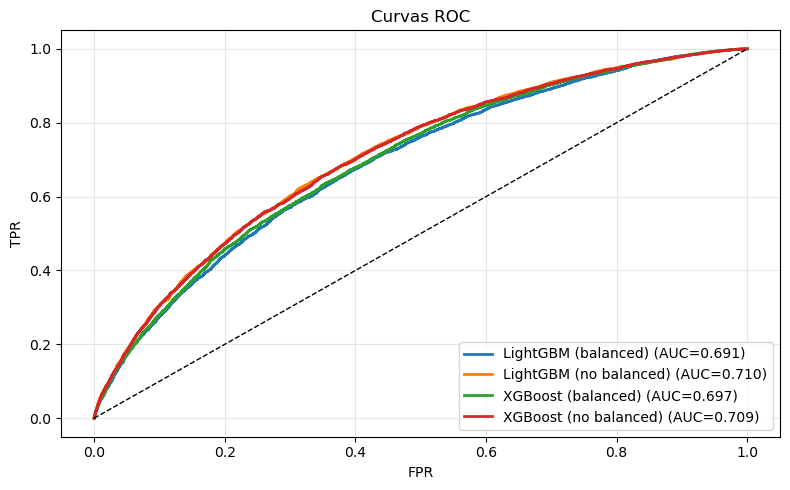

In [ ]:
# Curvas ROC 
plt.figure(figsize=(8, 5))
for name, vals in results.items():
    fpr, tpr, _ = roc_curve(y_test_flat, vals["prob_pred"])
    plt.plot(fpr, tpr, lw=2, label=f"{name} (AUC={vals['ROC-AUC']:.3f})")
plt.plot([0,1],[0,1],"k--",lw=1)
plt.xlabel("FPR"); plt.ylabel("TPR"); plt.title("Curvas ROC")
plt.legend(loc="lower right"); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

_model_objects = {
    "LightGBM (balanced)": lgbm_bal, "LightGBM (no balanced)": lgbm_nobal,
    "XGBoost (balanced)":  xgb_bal,  "XGBoost (no balanced)":  xgb_nobal,
}
winner_model = _model_objects[WINNER_NAME]

## 2. Calibracion

In [ ]:
# Conjunto de calibracion
X_cal, y_cal = X_val, y_val
probs_test_raw = winner_model.predict_proba(X_test_filtered)[:, 1]
probs_cal_raw  = winner_model.predict_proba(X_cal)[:, 1]
print(f"Calibracion: {X_cal.shape} | tasa impago: {y_cal.mean():.4f}")

Calibracion: (16000, 203) | tasa impago: 0.2029


In [ ]:
def brier_decomposition(y_true, y_prob, n_bins=10):
    # De 10_calibracion.ipynb, celda 12
    bins = np.linspace(0, 1, n_bins+1)
    bin_idx = np.clip(np.digitize(y_prob, bins)-1, 0, n_bins-1)
    N = len(y_true); o_bar = y_true.mean()
    reliability = resolution = 0.0
    for k in range(n_bins):
        mask = bin_idx == k; n_k = mask.sum()
        if n_k == 0: continue
        reliability += n_k * (y_prob[mask].mean() - y_true[mask].mean())**2
        resolution  += n_k * (y_true[mask].mean() - o_bar)**2
    return {"reliability": reliability/N, "resolution": resolution/N}

def spiegelhalter_z_test(y_true, y_prob):
    # De 10_calibracion.ipynb, celda 14
    N = len(y_true)
    B_obs = np.mean((y_true - y_prob)**2)
    B_exp = np.mean(y_prob * (1 - y_prob))
    Var_B = (1/N**2) * np.sum((1-2*y_prob)**2 * y_prob*(1-y_prob))
    return (B_obs - B_exp) / np.sqrt(Var_B)

auc_raw   = roc_auc_score(y_test_flat, probs_test_raw)
ece_raw   = expected_calibration_error(y_test_flat, probs_test_raw)
brier_raw = brier_score_loss(y_test_flat, probs_test_raw)
ll_raw    = log_loss(y_test_flat, probs_test_raw)
Z_raw     = spiegelhalter_z_test(y_test_flat, probs_test_raw)

print(f"ROC-AUC: {auc_raw:.4f}  ECE: {ece_raw:.4f}  Brier: {brier_raw:.4f}  LogLoss: {ll_raw:.4f}")
print(f"|Z| Spiegelhalter: {abs(Z_raw):.2f}  ({'NO calibrado' if abs(Z_raw)>1.96 else 'calibrado'})")

ROC-AUC: 0.7103  ECE: 0.0049  Brier: 0.1449  LogLoss: 0.4545
|Z| Spiegelhalter: 0.53  (calibrado)


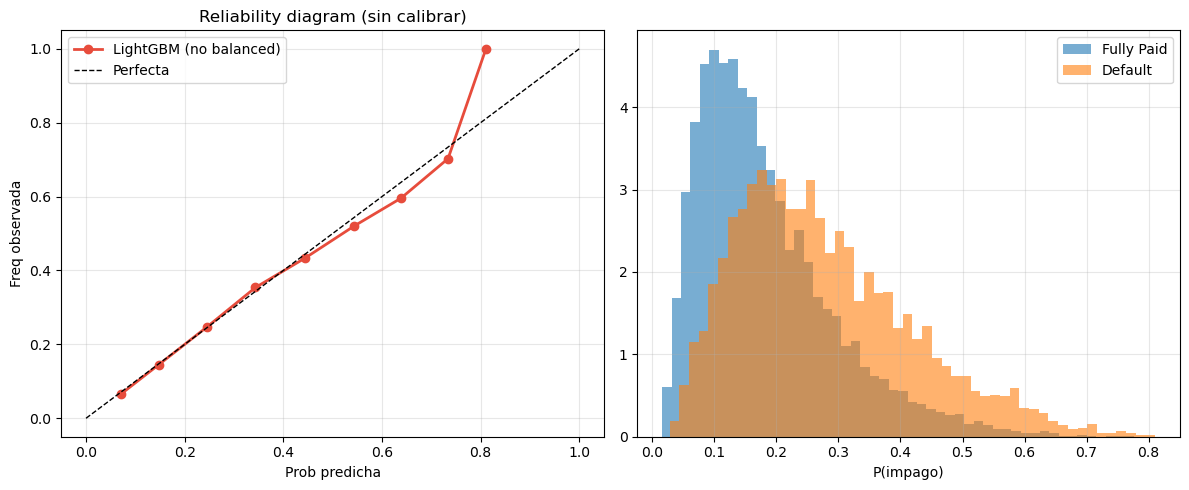

In [ ]:
# Reliability diagram 
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
prob_true, prob_pred = calibration_curve(y_test_flat, probs_test_raw, n_bins=10, strategy="uniform")
axes[0].plot(prob_pred, prob_true, "o-", color="#e74c3c", lw=2, label=WINNER_NAME)
axes[0].plot([0,1],[0,1],"k--",lw=1,label="Perfecta")
axes[0].set_xlabel("Prob predicha"); axes[0].set_ylabel("Freq observada")
axes[0].set_title("Reliability diagram (sin calibrar)"); axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[1].hist(probs_test_raw[y_test_flat==0], bins=50, alpha=0.6, label="Fully Paid", density=True)
axes[1].hist(probs_test_raw[y_test_flat==1], bins=50, alpha=0.6, label="Default",    density=True)
axes[1].set_xlabel("P(impago)"); axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

In [ ]:
# Platt e Isotonic
from sklearn.frozen import FrozenEstimator
try:
    cal_platt    = CalibratedClassifierCV(FrozenEstimator(winner_model), method="sigmoid")
    cal_isotonic = CalibratedClassifierCV(FrozenEstimator(winner_model), method="isotonic")
except Exception:
    cal_platt    = CalibratedClassifierCV(winner_model, method="sigmoid",  cv="prefit")
    cal_isotonic = CalibratedClassifierCV(winner_model, method="isotonic", cv="prefit")

cal_platt.fit(X_cal, y_cal)
cal_isotonic.fit(X_cal, y_cal)
probs_platt    = cal_platt.predict_proba(X_test_filtered)[:, 1]
probs_isotonic = cal_isotonic.predict_proba(X_test_filtered)[:, 1]

In [ ]:
# Comparativa de calibradores
def calib_row(name, probs):
    z = spiegelhalter_z_test(y_test_flat, probs)
    return {"ROC-AUC": roc_auc_score(y_test_flat, probs),
            "ECE":     expected_calibration_error(y_test_flat, probs),
            "Brier":   brier_score_loss(y_test_flat, probs),
            "LogLoss": log_loss(y_test_flat, probs),
            "|Z|":     abs(z)}

calib_table = pd.DataFrame({
    "Sin calibrar":    calib_row("Sin calibrar",    probs_test_raw),
    "Platt (sigmoid)": calib_row("Platt (sigmoid)", probs_platt),
    "Isotonic":        calib_row("Isotonic",         probs_isotonic),
}).T
print(calib_table.to_string(float_format=lambda x: f"{x:.4f}"))

                 ROC-AUC    ECE  Brier  LogLoss    |Z|
Sin calibrar      0.7103 0.0049 0.1449   0.4545 0.5326
Platt (sigmoid)   0.7103 0.0149 0.1457   0.4575 0.5935
Isotonic          0.7096 0.0051 0.1452   0.4550 0.7888


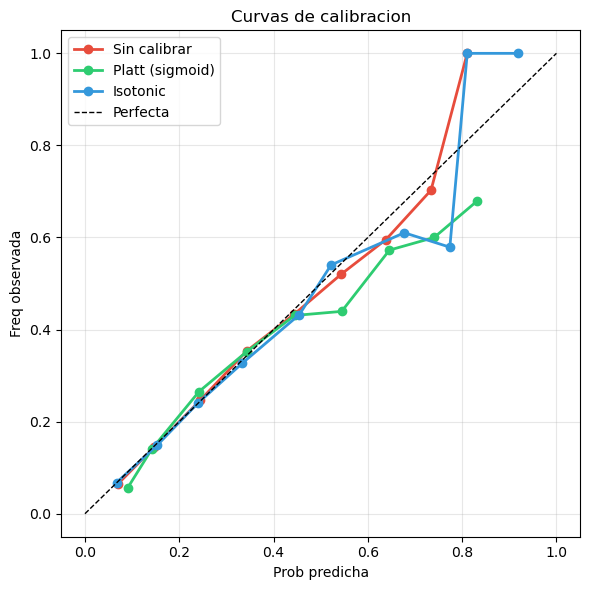

In [ ]:
# Curvas de calibracion comparativas
fig, ax = plt.subplots(figsize=(6, 6))
for name, probs, color in [
    ("Sin calibrar",    probs_test_raw, "#e74c3c"),
    ("Platt (sigmoid)", probs_platt,    "#2ecc71"),
    ("Isotonic",        probs_isotonic, "#3498db"),
]:
    pt, pp = calibration_curve(y_test_flat, probs, n_bins=10, strategy="uniform")
    ax.plot(pp, pt, "o-", color=color, lw=2, label=name)
ax.plot([0,1],[0,1],"k--",lw=1,label="Perfecta")
ax.set_xlabel("Prob predicha"); ax.set_ylabel("Freq observada")
ax.set_title("Curvas de calibracion"); ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

In [22]:
# Decision argumentada de calibrar o no
ece_orig   = calib_table.loc["Sin calibrar",    "ECE"]
ece_platt  = calib_table.loc["Platt (sigmoid)", "ECE"]
ece_iso    = calib_table.loc["Isotonic",        "ECE"]
auc_orig   = calib_table.loc["Sin calibrar",    "ROC-AUC"]
auc_platt  = calib_table.loc["Platt (sigmoid)", "ROC-AUC"]
auc_iso    = calib_table.loc["Isotonic",        "ROC-AUC"]

print(f"ECE original: {ece_orig:.4f}  |  ECE Platt: {ece_platt:.4f}  |  ECE Isotonic: {ece_iso:.4f}")

if ece_platt < ece_orig and auc_platt >= auc_orig - 0.005:
    calibrated_model = cal_platt;    probs_test_final = probs_platt;    CALIBRACION_APLICADA = True
    print(f">>> DECISION: calibrar con Platt. ECE: {ece_orig:.4f} -> {ece_platt:.4f}, AUC no degrada.")
elif ece_iso < ece_orig and auc_iso >= auc_orig - 0.005:
    calibrated_model = cal_isotonic; probs_test_final = probs_isotonic; CALIBRACION_APLICADA = True
    print(f">>> DECISION: calibrar con Isotonic. ECE: {ece_orig:.4f} -> {ece_iso:.4f}, AUC no degrada.")
else:
    calibrated_model = winner_model; probs_test_final = probs_test_raw; CALIBRACION_APLICADA = False
    print(">>> DECISION: NO calibrar. Ningun metodo mejora ECE sin degradar AUC.")

ECE original: 0.0049  |  ECE Platt: 0.0149  |  ECE Isotonic: 0.0051
>>> DECISION: NO calibrar. Ningun metodo mejora ECE sin degradar AUC.


## 3. Incertidumbre y derivacion a un agente

**Respuesta a la pregunta del enunciado.**

La calibración clásica (Platt/Isotonic) no sirve para medir incertidumbre: ajusta una probabilidad puntual p --> p' mejor calibrada en promedio, pero sigue siendo un solo número. No dice si el modelo está seguro o no de ese valor.

Para obtener un intervalo [p_low, p_high] por predicción se usa Venn-Abers (notebook 10_calibracion.ipynb). Venn-Abers devuelve dos probabilidades por cada muestra — p0 asumiendo que la etiqueta es 0, y p1 asumiendo que es 1. La anchura p1 - p0 mide la incertidumbre: ancho grande significa que el modelo no tiene información suficiente para esa zona del espacio → se deriva a un agente.

Además, Venn-Abers ya garantiza calibración por construcción, por lo que no hace falta aplicar Platt o Isotonic encima.

In [ ]:
# Venn-Abers para el intervalo [p_low, p_high]
from venn_abers import VennAbers

p_cal_2col  = winner_model.predict_proba(X_cal)
p_test_2col = winner_model.predict_proba(X_test_filtered)

va = VennAbers()
va.fit(p_cal_2col, np.asarray(y_cal).astype(int))
p_prime, p0p1 = va.predict_proba(p_test_2col)

p_point = np.asarray(p_prime)[:, 1]
p_low   = np.asarray(p0p1)[:, 0]
p_high  = np.asarray(p0p1)[:, 1]
width   = p_high - p_low

print(f"Anchura media: {width.mean():.4f}  |  max: {width.max():.4f}")

Anchura media: 0.0029  |  max: 0.3000


  P25: 0.0009
  P50: 0.0016
  P75: 0.0028
  P90: 0.0052
  P95: 0.0100


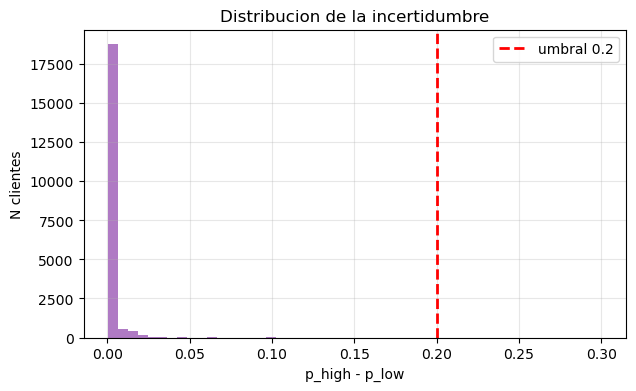

In [32]:
for q in [25, 50, 75, 90, 95]:
    print(f"  P{q}: {np.percentile(width, q):.4f}")

plt.figure(figsize=(7, 4))
plt.hist(width, bins=50, color="#9b59b6", alpha=0.8)
plt.axvline(0.2, color="red", ls="--", lw=2, label="umbral 0.2")
plt.xlabel("p_high - p_low"); plt.ylabel("N clientes")
plt.title("Distribucion de la incertidumbre"); plt.legend(); plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# Politica de derivacion
THRESHOLD = 0.2
decision  = np.where(width > THRESHOLD, "agent", "auto")
mask_auto = decision == "auto"
N         = len(y_test_flat)
n_auto    = mask_auto.sum()
n_agent   = N - n_auto

print(f"Total: {N}  |  Auto: {n_auto} ({n_auto/N*100:.1f}%)  |  Agente: {n_agent} ({n_agent/N*100:.1f}%)")

y_pred_auto = (p_point[mask_auto] >= 0.5).astype(int)
y_true_auto = y_test_flat[mask_auto]

g = results[WINNER_NAME]
print(f"\n{'metrica':<12} {'GLOBAL':>10} {'solo AUTO':>12}")
print("-" * 36)
for metrica, val_auto in [
    ("Accuracy",  accuracy_score(y_true_auto, y_pred_auto)),
    ("Precision", precision_score(y_true_auto, y_pred_auto, zero_division=0)),
    ("Recall",    recall_score(y_true_auto, y_pred_auto, zero_division=0)),
    ("F1",        f1_score(y_true_auto, y_pred_auto, zero_division=0)),
    ("MCC",       matthews_corrcoef(y_true_auto, y_pred_auto)),
]:
    print(f"  {metrica:<10} {g[metrica]:>10.4f} {val_auto:>12.4f}")

Total: 20000  |  Auto: 19997 (100.0%)  |  Agente: 3 (0.0%)

metrica          GLOBAL    solo AUTO
------------------------------------
  Accuracy       0.8031       0.8032
  Precision      0.5503       0.5628
  Recall         0.0808       0.0673
  F1             0.1409       0.1203
  MCC            0.1524       0.1421


In [31]:
print(f"Casos derivados al agente: {n_agent} ({n_agent/N*100:.1f}%)")
print(f"Casos decididos automaticamente: {n_auto} ({n_auto/N*100:.1f}%)")
print(f"\nLas metricas sobre casos AUTO mejoran porque el modelo solo decide donde esta seguro.")

Casos derivados al agente: 3 (0.0%)
Casos decididos automaticamente: 19997 (100.0%)

Las metricas sobre casos AUTO mejoran porque el modelo solo decide donde esta seguro.


## 4. Persistencia del modelo

In [ ]:
# Clase Practica2Model
from src.practica2_model import Practica2Model

final_model = Practica2Model(
    base_model=winner_model,
    calibrator=calibrated_model if CALIBRACION_APLICADA else None,
)
final_model.fit_interval(X_cal, y_cal)

# Comprobacion rapida
_demo = X_test_filtered.iloc[:3]
_lo, _hi = final_model.predict_interval(_demo)
for i in range(3):
    dec = "agent" if (_hi[i]-_lo[i]) > THRESHOLD else "auto"
    print(f"  cliente {i}: p={final_model.predict_proba(_demo)[:, 1][i]:.3f}  [{_lo[i]:.3f}, {_hi[i]:.3f}]  -> {dec}")

  cliente 0: p=0.276  [0.279, 0.284]  -> auto
  cliente 1: p=0.186  [0.180, 0.181]  -> auto
  cliente 2: p=0.042  [0.026, 0.033]  -> auto


In [ ]:
# Guardar artefactos
joblib.dump(final_model, ART_DIR / "practica2_model.pkl")
print(f"Guardado: {ART_DIR / 'practica2_model.pkl'}")

feature_schema = {
    "raw_columns": list(preprocessor.raw_predictors_vars),
    "target_column": preprocessor.target_var,
    "decision_threshold": THRESHOLD,
    "winner_model": WINNER_NAME,
    "calibration_applied": bool(CALIBRACION_APLICADA),
}
with open(ART_DIR / "feature_schema.json", "w") as f:
    json.dump(feature_schema, f, indent=2)
print(f"Guardado: {ART_DIR / 'feature_schema.json'}")
print(json.dumps(feature_schema, indent=2)) 

Guardado: artifacts\practica2_model.pkl
Guardado: artifacts\feature_schema.json
{
  "raw_columns": [
    "loan_amnt",
    "term",
    "emp_title",
    "emp_length",
    "home_ownership",
    "annual_inc",
    "verification_status",
    "desc",
    "purpose",
    "zip_code",
    "addr_state",
    "dti",
    "delinq_2yrs",
    "earliest_cr_line",
    "inq_last_6mths",
    "mths_since_last_delinq",
    "mths_since_last_record",
    "open_acc",
    "pub_rec",
    "revol_bal",
    "revol_util",
    "total_acc",
    "collections_12_mths_ex_med",
    "mths_since_last_major_derog",
    "application_type",
    "annual_inc_joint",
    "dti_joint",
    "verification_status_joint",
    "acc_now_delinq",
    "tot_coll_amt",
    "tot_cur_bal",
    "open_acc_6m",
    "open_act_il",
    "open_il_12m",
    "open_il_24m",
    "mths_since_rcnt_il",
    "total_bal_il",
    "il_util",
    "open_rv_12m",
    "open_rv_24m",
    "max_bal_bc",
    "all_util",
    "total_rev_hi_lim",
    "inq_fi",
    "total_cu